In [6]:
import os
import pandas as pd
import numpy as np

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

DATA_RAW = "../data_pipeline/data/raw"
DATA_PROC = "../data_pipeline/data/processed"

In [7]:
# pick our y target and x features for machine learning. 

panel = pd.read_csv(f"{DATA_PROC}/model_panel.csv", parse_dates=["date"])
feature_cols = [c for c in panel.columns if c not in ["date", "ticker", "fwd_ret"]]
panel = panel.dropna(subset=feature_cols + ["fwd_ret"])
X = panel[feature_cols]
y = panel["fwd_ret"]

In [8]:
# sort panel by date (not random so the model doesn't have a bias looking ahead)

panel = panel.sort_values("date")
dates = panel["date"].unique()

cutoff = dates[int(len(dates) * 0.7)]
train_mask = panel["date"] <= cutoff
test_mask  = panel["date"] > cutoff

X_train = X[train_mask]
X_test  = X[test_mask]
y_train = y[train_mask]
y_test  = y[test_mask]

/tmp/ipykernel_2024/822652610.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  X_train = X[train_mask]
/tmp/ipykernel_2024/822652610.py:11: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  X_test  = X[test_mask]


In [9]:
# build ridge regression pipeline
# standardize features and fit ridge regression. 
# use ridge regession training to reduce variance. 

ridge = Pipeline([("scaler", StandardScaler()), ("model", Ridge(alpha=1.0))])


In [10]:
# fit the model and predict
ridge.fit(X_train, y_train)
y_pred_test = ridge.predict(X_test)

# model has learned mapping to predict the expected 21 day return based on the X factors given. 

In [11]:
# check on the R^2 and Mean Squared Error:

from sklearn.metrics import r2_score, mean_squared_error

r2 = r2_score(y_test, y_pred_test)
mse = mean_squared_error(y_test, y_pred_test)

print("Test R²:", r2)
print("Test MSE:", mse)

Test R²: 0.008959880012291976
Test MSE: 0.0069916935868758676


R^2 value of .01 means that the data is incredibly noisy, which should be expected for financial data

Nexty we'll look at IC = cross-sectional correlation between predicted and realized returns on each date.

In [12]:
# attach prediction

panel_test = panel.loc[test_mask].copy()
panel_test["y_pred"] = y_pred_test

panel_test.shape


(33720, 7)

In [13]:
ics = []

for d, group in panel_test.groupby("date"):
    # Need at least 2 distinct predictions or corr = NaN
    if group["y_pred"].nunique() < 2:
        continue
    ic = group["y_pred"].corr(group["fwd_ret"])
    ics.append(ic)

ics = np.array(ics)

print("Number of IC observations:", len(ics))
print("Mean IC:", ics.mean())
print("Std of IC:", ics.std())

Number of IC observations: 562
Mean IC: -0.0010579667517932767
Std of IC: 0.1372310080139896


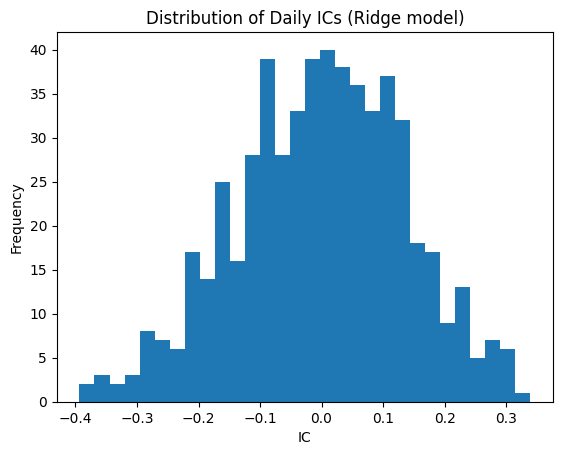

In [14]:
import matplotlib.pyplot as plt

plt.hist(ics, bins=30)
plt.title("Distribution of Daily ICs (Ridge model)")
plt.xlabel("IC")
plt.ylabel("Frequency")
plt.show()

Quick Recap of where we are:

We did all this to calculate IC (Information Coefficient)
IC is a measure of how good our model is at ranking stocks. 
This is different from R^2 because it doesn't need to tell us if our guess was exact, it just needs to tell us if our picks do better.
IE did the stocks my model like actually perform better than the stocks it disliked. 
Essentially it's just a correlation between predicted and actual returns. 

MY UC VALUE is coming in at .00084
This is not a very predictive baseline BUT this is to be expected since it's a super simple model with only 3 factors.
So while the baseline isn't great, it is positive. Meaning we theoretically guess slightly more right than wrong, but it's essentially random. Which I'd say is a great first step since it means that its not flat wrong. 

In [15]:
# create a daily signal matrix

signals = panel_test.pivot(index="date", columns="ticker", values="y_pred")


In [16]:
# Normalize into weights.
# pick top 30% performers to go long
# pick bottom 30% performers to go short

def long_short_weights(row):
    longs = row >= row.quantile(0.70)
    shorts = row <= row.quantile(0.30)
    w = longs.astype(int) - shorts.astype(int)
    return w / w.abs().sum()

weights = signals.apply(long_short_weights, axis=1)

We want to simulate a portfolio that:
* On each rebalance date (each row in weights), holds some weight in each stock.
* For that date, earns the forward return of each stock (fwd_ret) over the horizon (21 trading days).
* Combines those into a portfolio return for that period.
* Chains those returns over time into a portfolio value curve.

In [ ]:
# we want to reshape panel_test into a 2D matrix where:
# rows= dates, columns = tickers, values = forward return for that ticket from that date to horizon

fwd_ret_mat = panel_test.pivot(index="date", columns="ticker", values="fwd_ret")
fwd_ret_mat.head()


ticker,AAPL,ABBV,ACN,ADBE,AMAT,AMD,AMT,AMZN,AVGO,BA,...,QCOM,SBUX,SPGI,TMO,TXN,UNH,UPS,V,WMT,XOM
date,,,,,,,,,,,,,,,,,,,,,
2023-07-31,-0.078623,-0.022672,0.016986,0.001985,-0.040773,-0.091625,-0.057152,0.007034,-0.043021,-0.048724,...,-0.137473,-0.036470,-0.002091,-0.029652,-0.054213,-0.023125,-0.093245,0.036218,-0.003913,0.056594
2023-08-01,-0.061498,-0.013304,0.022443,-0.010253,-0.008475,-0.074126,-0.046293,0.009201,-0.009704,-0.048566,...,-0.139139,-0.018620,-0.002776,0.012303,-0.051722,-0.026739,-0.073871,0.033952,0.004748,0.032359
2023-08-02,-0.039398,-0.001481,0.007104,-0.006811,-0.008862,-0.093622,-0.046852,0.025666,-0.030130,-0.038486,...,-0.136341,-0.014723,-0.012592,0.024109,-0.051242,-0.026172,-0.064319,0.028831,0.016737,0.048480
2023-08-03,-0.023140,-0.016200,0.018850,0.054762,0.039105,-0.033196,-0.048788,0.076437,0.034282,-0.031766,...,-0.107752,-0.040834,-0.006288,0.006032,-0.025400,-0.055903,-0.067711,0.036126,0.024922,0.064692
2023-08-04,-0.007607,-0.005703,0.033456,0.075321,0.044070,-0.032700,-0.026703,0.071445,-0.014080,-0.034405,...,-0.021002,-0.037207,0.029811,0.016120,-0.011467,-0.056689,-0.065992,0.041115,0.018111,0.068433


In [23]:
# weights: “how much I invest in each stock on this date”
# fwd_ret_mat: “what each stock returns over the next 21 days”

# lets align weights and rwd_ret_mat to make sure they share the same dates and ticket columns to avoid misalignment. 

weights_aligned, fwd_ret_aligned = weights.align(fwd_ret_mat, join="inner", axis=0)
weights_aligned, fwd_ret_aligned = weights_aligned.align(fwd_ret_aligned, join="inner", axis=1)

weights_aligned.shape, fwd_ret_aligned.shape

((562, 60), (562, 60))

In [ ]:
# compute portfolio return for each period
# for each date: portfolio return = sum over all tickers of weight-in-ticker x forward-return-of-ticker

port_ret = (weights_aligned * fwd_ret_aligned).sum(axis=1)
port_ret.head()

# port_ret is our strategies time series of per-period returns

date
2023-07-31   -0.002158
2023-08-01    0.006802
2023-08-02   -0.002302
2023-08-03    0.007779
2023-08-04   -0.014081
dtype: float64

In [29]:
# now lets turn our returns into a portfolio value curve. 
# if I start with $1 and compound these returns. what does my equity curve look like?

initial_capital = 1.0
portfolio_value = initial_capital * (1 + port_ret).cumprod()
portfolio_value.head()

date
2023-07-31    0.997842
2023-08-01    1.004629
2023-08-02    1.002317
2023-08-03    1.010113
2023-08-04    0.995889
dtype: float64

Now that we have the return series (port_ret) and the equity curve (portfolio_value), we can compute performance stats:
* Annualized return
* Annualized volatility
* Sharpe ratio
* Max drawdown
* Turnover

In [ ]:
# annualize return

n_periods = len(port_ret)
periods_per_year = 252 / 21  # ~12 periods per year

total_return = portfolio_value.iloc[-1] / portfolio_value.iloc[0] - 1

ann_ret = (1 + total_return) ** (periods_per_year / n_periods) - 1
ann_ret

# on average, how much did this strategy make per year?
# our IC earlier was essentially 0, so this number being less than 1% isn't surprising at this stage. 


0.003315191125755179

In [ ]:
# annualize volatility

period_ret_std = port_ret.std()
ann_vol = period_ret_std * np.sqrt(periods_per_year)
ann_vol

# how bumpy was the year?

0.04529354685373349

In [ ]:
# Sharpe Ratio

sharpe = ann_ret / ann_vol
sharpe

# is the return worth the risk or is it just noisy? (.07 is a little meh)
# the number shows we're taking risk but not getting a lot of return for it. (below a score of 1)

0.07319345372666287

In [ ]:
# max Drawdown = worst peak-to-trough loss during the backtest
# how much "pain" for an investor. The largest loss from a previous high

running_max = portfolio_value.cummax()
drawdown = portfolio_value / running_max - 1
max_dd = drawdown.min()
max_dd

# this strategy so far lost a big chunk from it's peak. 

-0.34187409734794394

In [ ]:
# Turnover
# How much does the portfolio change from one period to the next?


# Absolute change in weights from one period to the next
weight_changes = weights_aligned.diff().abs()

# Sum across tickers, average across time
daily_turnover = weight_changes.sum(axis=1).mean()
daily_turnover

# this number shows how much of portfolio I'm selling and buying over the 21 day period.
# above 1 means I'm dismantling and rebuilding the whole thing more than once, not great. 


1.3920521945432975